# Lung-PET-CT-Dx: Data Exploration for Lung Cancer Classification

This notebook performs exploratory data analysis on the **Lung-PET-CT-Dx** chest CT dataset to assess data suitability for training ResNet, DenseNet, and Vision Transformer models.

**Dataset**: Lung-PET-CT-Dx  
**Classes** (derived from patient ID letter):
| Letter | Diagnosis |
|--------|-----------|
| A | Adenocarcinoma |
| B | Small Cell Carcinoma |
| E | Large Cell Carcinoma |
| G | Squamous Cell Carcinoma |

**Imaging parameters**:
- Mediastinum window: W=350 HU, L=40 HU
- Lung window: W=1400 HU, L=-700 HU
- 2 mm slice-thick reconstructions, lung settings
- CT slice interval: 0.625–5 mm
- Scanning modes: plain, contrast, 3D reconstruction

## 1. Setup and Imports

In [1]:
import os
import re
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# Class mapping based on patient ID letter
CLASS_MAP = {
    'A': 'Adenocarcinoma',
    'B': 'Small Cell Carcinoma',
    'E': 'Large Cell Carcinoma',
    'G': 'Squamous Cell Carcinoma',
}


def safe_load_nifti(path):
    """Load NIfTI volume data, handling VoidDType / RGB / slope-intercept issues.
    
    Some NIfTI files from dcm2niix have unset scl_slope/scl_inter (None),
    which causes DTypePromotionError with numpy >=2.0 when nibabel tries
    to apply scaling. This function falls back to raw dataobj loading.
    """
    img = nib.load(path)
    try:
        # Try standard loading
        data = img.get_fdata(dtype=np.float32)
    except Exception:
        # Fallback: load raw data without applying scaling first
        try:
            raw_data = np.array(img.dataobj)
        except Exception:
            raise

        # Handle RGB / structured arrays (e.g. from secondary captures)
        if raw_data.dtype.names is not None:
             # If it has named fields (like R, G, B)
             if 'R' in raw_data.dtype.names:
                 # Assume grayscale content in RGB container, take Red channel
                 data = raw_data['R'].astype(np.float32)
             else:
                 # Fallback for other structured types: take first field
                 data = raw_data[raw_data.dtype.names[0]].astype(np.float32)
        else:
            # Standard scalar data
            data = raw_data.astype(np.float32)
            
    return img, data


print("Setup complete.")

Setup complete.


## 2. Data Discovery and Inventory

In [2]:
ROOT_DIR = "/home/data/Lung-PET-CT-Dx"

def parse_filename(filepath):
    """Parse patient ID, class letter, and series UID from filename.
    
    Naming convention: Lung_Dx-{Letter}{Number}_{series_uid}.nii.gz
    """
    basename = os.path.basename(filepath)
    # Remove extension(s)
    name = basename.replace('.nii.gz', '').replace('.nii', '').replace('.json', '')
    
    # Extract patient_id (e.g., Lung_Dx-A0001) and series_uid
    match = re.match(r'(Lung_Dx-([A-Z])(\d+))_(.*)', name)
    if match:
        patient_id = match.group(1)       # e.g., Lung_Dx-A0001
        class_letter = match.group(2)      # e.g., A
        patient_num = match.group(3)       # e.g., 0001
        series_uid = match.group(4)        # e.g., 1.3.6.1...
        diagnosis = CLASS_MAP.get(class_letter, 'Unknown')
        return patient_id, class_letter, patient_num, series_uid, diagnosis
    return None, None, None, None, None


def discover_data(root_dir):
    """Find all NIfTI volumes and their paired JSON metadata files."""
    nii_files = sorted(glob.glob(os.path.join(root_dir, "*.nii.gz")))
    
    records = []
    for nii_path in nii_files:
        patient_id, class_letter, patient_num, series_uid, diagnosis = parse_filename(nii_path)
        if patient_id is None:
            continue
        
        # Find matching JSON
        json_path = nii_path.replace('.nii.gz', '.json')
        has_json = os.path.exists(json_path)
        
        records.append({
            'patient_id': patient_id,
            'class_letter': class_letter,
            'patient_num': patient_num,
            'series_uid': series_uid,
            'diagnosis': diagnosis,
            'volume_path': nii_path,
            'json_path': json_path if has_json else None,
            'has_json': has_json,
        })
    
    return pd.DataFrame(records)


df = discover_data(ROOT_DIR)

print(f"Total NIfTI volumes: {len(df)}")
print(f"Volumes with JSON metadata: {df['has_json'].sum()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"\n--- Class distribution (volumes) ---")
print(df['diagnosis'].value_counts().to_string())
print(f"\n--- Class distribution (patients) ---")
print(df.groupby('diagnosis')['patient_id'].nunique().to_string())
print(f"\n--- Series per patient ---")
series_per_patient = df.groupby('patient_id').size()
print(f"  Min: {series_per_patient.min()}, Max: {series_per_patient.max()}, "
      f"Median: {series_per_patient.median():.0f}, Mean: {series_per_patient.mean():.1f}")
df.head(10)

Total NIfTI volumes: 1350
Volumes with JSON metadata: 1106
Unique patients: 355

--- Class distribution (volumes) ---
diagnosis
Adenocarcinoma             1002
Squamous Cell Carcinoma     225
Small Cell Carcinoma        112
Large Cell Carcinoma         11

--- Class distribution (patients) ---
diagnosis
Adenocarcinoma             251
Large Cell Carcinoma         5
Small Cell Carcinoma        38
Squamous Cell Carcinoma     61

--- Series per patient ---
  Min: 1, Max: 14, Median: 4, Mean: 3.8


,patient_id,class_letter,patient_num,series_uid,diagnosis,volume_path,json_path,has_json
0,Lung_Dx-A0001,A,0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.213534032021...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,True
1,Lung_Dx-A0001,A,0001,1.3.6.1.4.1.14519.5.2.1.6655.2359.257508444832...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0001_1.3.6....,True
2,Lung_Dx-A0002,A,0002,1.3.6.1.4.1.14519.5.2.1.6655.2359.207154000096...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0002_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0002_1.3.6....,True
3,Lung_Dx-A0002,A,0002,1.3.6.1.4.1.14519.5.2.1.6655.2359.241981550240...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0002_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0002_1.3.6....,True
4,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.124466459064...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True
5,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.144797390935...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True
6,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.291101486042...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True
7,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.312598322891...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True
8,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.466719587716...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True
9,Lung_Dx-A0003,A,0003,1.3.6.1.4.1.14519.5.2.1.6655.2359.516695927127...,Adenocarcinoma,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,/home/data/Lung-PET-CT-Dx/Lung_Dx-A0003_1.3.6....,True


## 3. Class Balance Visualization

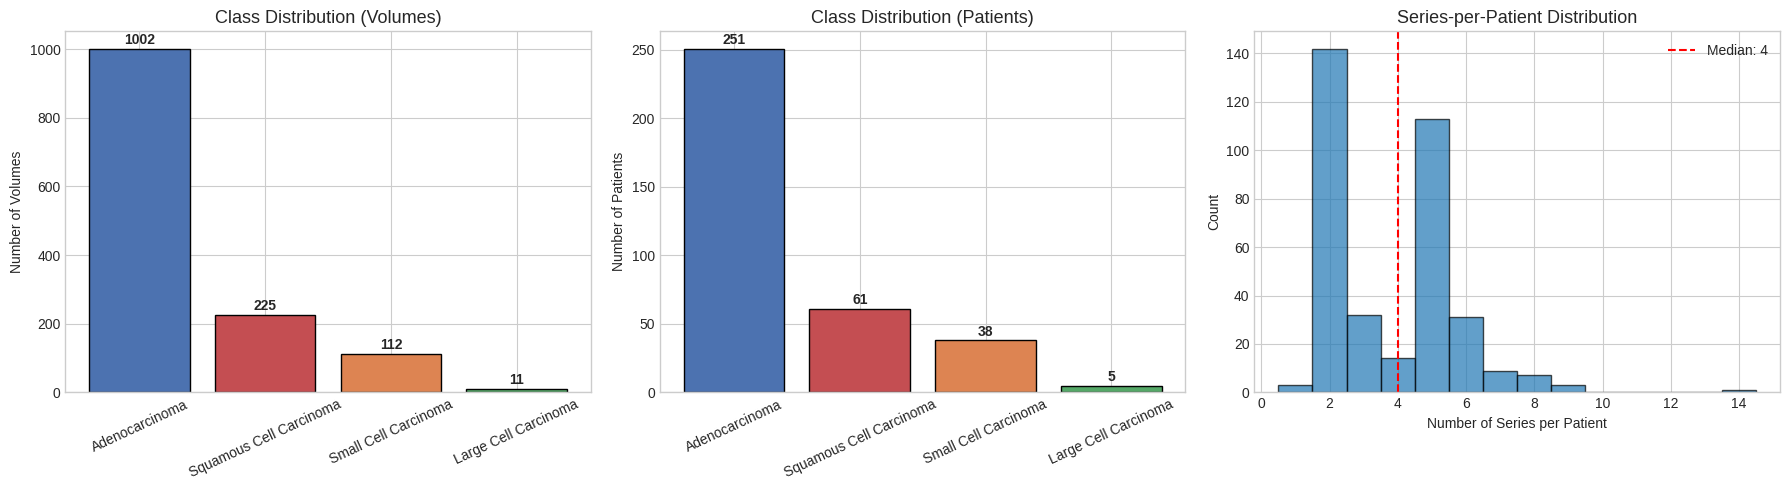


Imbalance ratio (max/min volumes): 91.1x
Imbalance ratio (max/min patients): 50.2x


In [3]:
COLOR_MAP = {
    'Adenocarcinoma': '#4C72B0',
    'Small Cell Carcinoma': '#DD8452',
    'Large Cell Carcinoma': '#55A868',
    'Squamous Cell Carcinoma': '#C44E52',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Volume-level class distribution ---
vol_counts = df['diagnosis'].value_counts()
colors = [COLOR_MAP[d] for d in vol_counts.index]
bars = axes[0].bar(vol_counts.index, vol_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Volumes)', fontsize=13)
axes[0].set_ylabel('Number of Volumes')
axes[0].tick_params(axis='x', rotation=25)
for bar, val in zip(bars, vol_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')

# --- Patient-level class distribution ---
pat_counts = df.groupby('diagnosis')['patient_id'].nunique().reindex(vol_counts.index)
colors_p = [COLOR_MAP[d] for d in pat_counts.index]
bars_p = axes[1].bar(pat_counts.index, pat_counts.values, color=colors_p, edgecolor='black')
axes[1].set_title('Class Distribution (Patients)', fontsize=13)
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=25)
for bar, val in zip(bars_p, pat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontweight='bold')

# --- Series per patient ---
series_per_patient = df.groupby('patient_id').size()
axes[2].hist(series_per_patient.values, bins=range(1, series_per_patient.max() + 2),
             edgecolor='black', alpha=0.7, align='left')
axes[2].set_xlabel('Number of Series per Patient')
axes[2].set_ylabel('Count')
axes[2].set_title('Series-per-Patient Distribution', fontsize=13)
axes[2].axvline(series_per_patient.median(), color='red', linestyle='--',
                label=f'Median: {series_per_patient.median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print imbalance ratio
print(f"\nImbalance ratio (max/min volumes): {vol_counts.max() / vol_counts.min():.1f}x")
print(f"Imbalance ratio (max/min patients): {pat_counts.max() / pat_counts.min():.1f}x")

## 4. JSON Metadata Analysis (Acquisition Parameters)

In [4]:
def load_json_metadata(json_path):
    """Load and flatten relevant fields from a sidecar JSON."""
    try:
        with open(json_path) as f:
            meta = json.load(f)
        return {
            'Modality': meta.get('Modality'),
            'Manufacturer': meta.get('Manufacturer'),
            'Model': meta.get('ManufacturersModelName'),
            'SeriesDescription': meta.get('SeriesDescription'),
            'ProtocolName': meta.get('ProtocolName'),
            'ScanOptions': meta.get('ScanOptions'),
            'ConvolutionKernel': meta.get('ConvolutionKernel'),
            'SliceThickness_json': meta.get('SliceThickness'),
            'XRayTubeCurrent': meta.get('XRayTubeCurrent'),
            'XRayExposure': meta.get('XRayExposure'),
            'PatientPosition': meta.get('PatientPosition'),
            'ImageType': str(meta.get('ImageType', [])),
        }
    except Exception as e:
        print(f"Error reading {json_path}: {e}")
        return None


# Load JSON metadata for all volumes that have it
print("Loading JSON metadata...")
json_records = []
for _, row in df[df['has_json']].iterrows():
    meta = load_json_metadata(row['json_path'])
    if meta:
        meta['patient_id'] = row['patient_id']
        meta['series_uid'] = row['series_uid']
        meta['diagnosis'] = row['diagnosis']
        json_records.append(meta)

df_json = pd.DataFrame(json_records)
print(f"Loaded metadata for {len(df_json)} volumes\n")

# Modality breakdown (CT vs PT)
print("=== Modality ===")
print(df_json['Modality'].value_counts().to_string())

print("\n=== Manufacturer ===")
print(df_json['Manufacturer'].value_counts().to_string())

print("\n=== Scanner Model ===")
print(df_json['Model'].value_counts().head(10).to_string())

print("\n=== Convolution Kernel ===")
print(df_json['ConvolutionKernel'].value_counts().head(10).to_string())

print("\n=== Patient Position ===")
print(df_json['PatientPosition'].value_counts().to_string())

print("\n=== Series Description (top 15) ===")
print(df_json['SeriesDescription'].value_counts().head(15).to_string())

Loading JSON metadata...
Loaded metadata for 1106 volumes

=== Modality ===
Modality
CT    1069
PT      37

=== Manufacturer ===
Manufacturer
Siemens    618
GE         369
Philips    119

=== Scanner Model ===
Model
Biograph 64           406
Discovery CT750 HD    209
LightSpeed VCT        120
Sensation 10          112
iCT 256                70
Biograph64             63
Brilliance16           49
Biograph 64_mCT        37
LightSpeed Pro 16      19
Optima CT660           15

=== Convolution Kernel ===
ConvolutionKernel
STANDARD         188
LUNG             164
B70f             141
B31f              59
B40f              55
B                 52
XYZ Gauss5.00     37
YB                36
B30f              34
L                 25

=== Patient Position ===
PatientPosition
HFS    814
FFS    292

=== Series Description (top 15) ===
SeriesDescription
Range-CT WB  1.0  B30f-Tra-<ALPHA Range>    245
5mm                                         130
5mm Lung SS50                                91
Thora

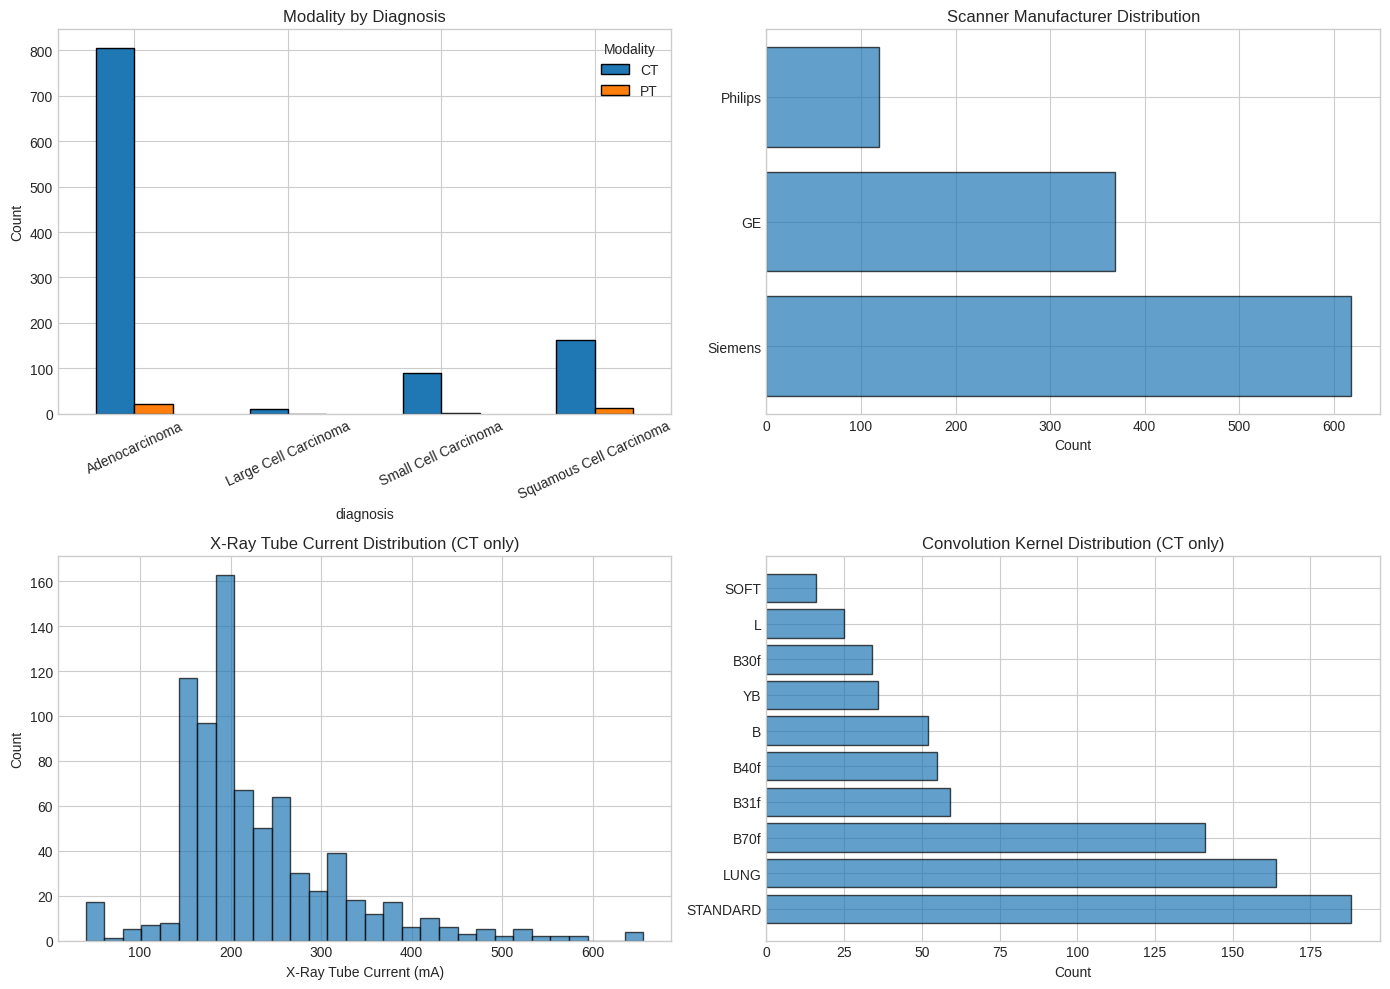

In [5]:
# Visualize acquisition parameter distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Modality distribution by class
modality_class = pd.crosstab(df_json['diagnosis'], df_json['Modality'])
modality_class.plot(kind='bar', ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Modality by Diagnosis')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].legend(title='Modality')

# Manufacturer distribution
mfr_counts = df_json['Manufacturer'].value_counts()
axes[0, 1].barh(mfr_counts.index, mfr_counts.values, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Scanner Manufacturer Distribution')

# X-ray tube current (CT only)
ct_json = df_json[df_json['Modality'] == 'CT']
if ct_json['XRayTubeCurrent'].notna().sum() > 0:
    axes[1, 0].hist(ct_json['XRayTubeCurrent'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('X-Ray Tube Current (mA)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('X-Ray Tube Current Distribution (CT only)')

# Convolution kernel distribution
kernel_counts = ct_json['ConvolutionKernel'].dropna().value_counts().head(10)
if len(kernel_counts) > 0:
    axes[1, 1].barh(kernel_counts.index.astype(str), kernel_counts.values, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Count')
    axes[1, 1].set_title('Convolution Kernel Distribution (CT only)')

plt.tight_layout()
plt.savefig('acquisition_parameters.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. NIfTI Volume Metadata (Dimensions & Voxel Spacing)

In [6]:
def extract_nifti_metadata(volume_path):
    """Extract shape and voxel spacing from a NIfTI header (fast, no data load)."""
    try:
        img = nib.load(volume_path)
        header = img.header
        shape = img.shape
        zooms = header.get_zooms()
        dtype = header.get_data_dtype()
        
        return {
            'dim_x': shape[0] if len(shape) > 0 else None,
            'dim_y': shape[1] if len(shape) > 1 else None,
            'dim_z': shape[2] if len(shape) > 2 else None,
            'n_dims': len(shape),
            'spacing_x': round(float(zooms[0]), 4) if len(zooms) > 0 else None,
            'spacing_y': round(float(zooms[1]), 4) if len(zooms) > 1 else None,
            'spacing_z': round(float(zooms[2]), 4) if len(zooms) > 2 else None,
            'dtype': str(dtype),
        }
    except Exception as e:
        print(f"Error loading {volume_path}: {e}")
        return None


print("Extracting NIfTI metadata (header only, fast)...")
nifti_records = []
for _, row in df.iterrows():
    meta = extract_nifti_metadata(row['volume_path'])
    if meta:
        meta['patient_id'] = row['patient_id']
        meta['series_uid'] = row['series_uid']
        meta['diagnosis'] = row['diagnosis']
        nifti_records.append(meta)

df_nifti = pd.DataFrame(nifti_records)
print(f"Extracted metadata from {len(df_nifti)} volumes\n")

print("=" * 60)
print("VOLUME DIMENSIONS SUMMARY")
print("=" * 60)
print(df_nifti[['dim_x', 'dim_y', 'dim_z']].describe().round(1))

print("\n" + "=" * 60)
print("VOXEL SPACING SUMMARY (mm)")
print("=" * 60)
print(df_nifti[['spacing_x', 'spacing_y', 'spacing_z']].describe().round(4))

print(f"\nUnique in-plane spacings: {df_nifti['spacing_x'].nunique()}")
print(f"Unique slice spacings: {df_nifti['spacing_z'].nunique()}")
print(f"Data types: {df_nifti['dtype'].value_counts().to_dict()}")

Extracting NIfTI metadata (header only, fast)...
Extracted metadata from 1350 volumes

VOLUME DIMENSIONS SUMMARY
        dim_x   dim_y   dim_z
count  1350.0  1350.0  1350.0
mean    481.4   481.3   183.5
std      93.6    93.3   145.6
min     200.0   200.0     1.0
25%     512.0   512.0    52.0
50%     512.0   512.0   181.0
75%     512.0   512.0   296.0
max     888.0   752.0   852.0

VOXEL SPACING SUMMARY (mm)
       spacing_x  spacing_y  spacing_z
count  1350.0000  1350.0000  1350.0000
mean      1.1234     1.1234     3.3578
std       0.9827     0.9827     5.4490
min       0.5449     0.5449     0.6250
25%       0.7031     0.7031     1.0000
50%       0.7812     0.7812     2.0299
75%       1.0000     1.0000     5.0000
max       4.0728     4.0728   141.2500

Unique in-plane spacings: 112
Unique slice spacings: 28
Data types: {'int16': 929, "[('R', 'u1'), ('G', 'u1'), ('B', 'u1')]": 288, 'uint16': 74, 'float32': 59}


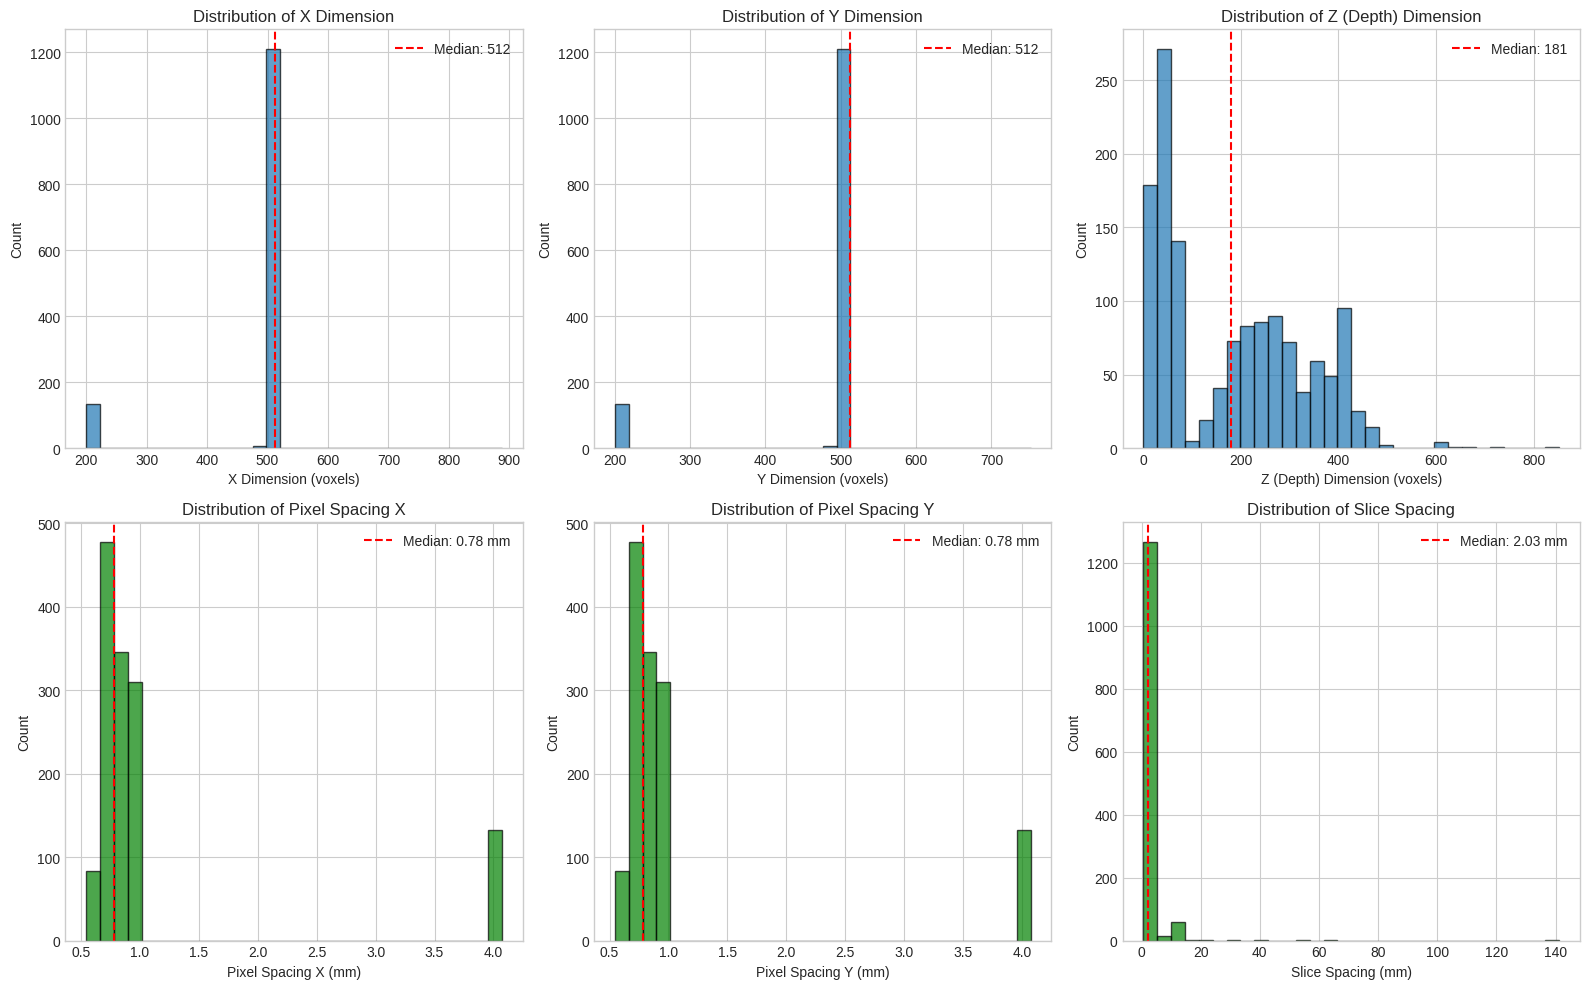

RESAMPLING ASSESSMENT

Std of voxel spacing:
spacing_x    0.9827
spacing_y    0.9827
spacing_z    5.4490

⚠️  Significant variation in voxel spacing. Consider resampling to isotropic voxels.


In [7]:
# Visualize dimension and spacing distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Dimensions ---
for i, (col, label) in enumerate([('dim_x', 'X'), ('dim_y', 'Y'), ('dim_z', 'Z (Depth)')]):
    vals = df_nifti[col].dropna()
    axes[0, i].hist(vals, bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_xlabel(f'{label} Dimension (voxels)')
    axes[0, i].set_ylabel('Count')
    axes[0, i].set_title(f'Distribution of {label} Dimension')
    axes[0, i].axvline(vals.median(), color='red', linestyle='--',
                       label=f'Median: {vals.median():.0f}')
    axes[0, i].legend()

# --- Spacing ---
spacing_cols = [('spacing_x', 'Pixel Spacing X'), ('spacing_y', 'Pixel Spacing Y'), ('spacing_z', 'Slice Spacing')]
for i, (col, label) in enumerate(spacing_cols):
    vals = df_nifti[col].dropna()
    axes[1, i].hist(vals, bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1, i].set_xlabel(f'{label} (mm)')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'Distribution of {label}')
    axes[1, i].axvline(vals.median(), color='red', linestyle='--',
                       label=f'Median: {vals.median():.2f} mm')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig('dimension_spacing_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Resampling assessment
print("=" * 60)
print("RESAMPLING ASSESSMENT")
print("=" * 60)
spacing_std = df_nifti[['spacing_x', 'spacing_y', 'spacing_z']].std()
print(f"\nStd of voxel spacing:\n{spacing_std.round(4).to_string()}")
if spacing_std.max() > 0.5:
    print("\n⚠️  Significant variation in voxel spacing. Consider resampling to isotropic voxels.")
else:
    print("\n✓  Voxel spacing is relatively consistent.")

In [8]:
# Dimension/spacing breakdown by diagnosis
print("=" * 60)
print("DIMENSIONS BY DIAGNOSIS")
print("=" * 60)
for diag in sorted(df_nifti['diagnosis'].unique()):
    subset = df_nifti[df_nifti['diagnosis'] == diag]
    print(f"\n--- {diag} (n={len(subset)}) ---")
    print(subset[['dim_x', 'dim_y', 'dim_z', 'spacing_x', 'spacing_y', 'spacing_z']].describe().round(2).loc[['mean', 'std', 'min', 'max']])

DIMENSIONS BY DIAGNOSIS

--- Adenocarcinoma (n=1002) ---
      dim_x   dim_y   dim_z  spacing_x  spacing_y  spacing_z
mean  482.6  482.46  182.83       1.11       1.11       3.45
std    92.3   91.81  148.23       0.97       0.97       6.16
min   200.0  200.00    1.00       0.54       0.54       0.62
max   888.0  752.00  852.00       4.07       4.07     141.25

--- Large Cell Carcinoma (n=11) ---
      dim_x  dim_y  dim_z  spacing_x  spacing_y  spacing_z
mean  512.0  512.0  46.36       0.69       0.69       5.91
std     0.0    0.0  21.34       0.04       0.04       2.02
min   512.0  512.0   1.00       0.66       0.66       5.00
max   512.0  512.0  83.00       0.76       0.76      10.00

--- Small Cell Carcinoma (n=112) ---
       dim_x   dim_y   dim_z  spacing_x  spacing_y  spacing_z
mean  486.93  486.93  141.81       1.05       1.05       3.88
std    85.20   85.20  130.68       0.91       0.91       2.68
min   200.00  200.00    1.00       0.62       0.62       0.70
max   512.00  512.00

In [9]:
# Specific breakdown of Slice Thickness (Z-spacing in mm)
print("=" * 60)
print("SLICE THICKNESS (mm) DISTRIBUTION")
print("=" * 60)

if 'df_nifti' in locals():
    slice_stats = df_nifti['spacing_z'].describe()
    print(slice_stats.round(4))
    
    print("\nMost common slice thicknesses (Top 5):")
    print(df_nifti['spacing_z'].value_counts().head(5))
else:
    print("Please run the NIfTI metadata extraction cell first.")

SLICE THICKNESS (mm) DISTRIBUTION
count    1350.0000
mean        3.3578
std         5.4490
min         0.6250
25%         1.0000
50%         2.0299
75%         5.0000
max       141.2500
Name: spacing_z, dtype: float64

Most common slice thicknesses (Top 5):
spacing_z
5.0     484
1.0     379
0.7     227
3.0      72
10.0     57
Name: count, dtype: int64


## 6. Intensity Analysis (Hounsfield Units)

Sampling a subset of volumes for intensity statistics to keep runtime reasonable.

In [10]:
def analyze_intensity(volume_path):
    """Compute intensity statistics for one volume."""
    try:
        _, data = safe_load_nifti(volume_path)
        
        return {
            'hu_min': float(np.min(data)),
            'hu_max': float(np.max(data)),
            'hu_mean': float(np.mean(data)),
            'hu_std': float(np.std(data)),
            'hu_median': float(np.median(data)),
            'hu_p01': float(np.percentile(data, 1)),
            'hu_p99': float(np.percentile(data, 99)),
        }
    except Exception as e:
        print(f"Error: {e}")
        return None


# Sample up to N volumes per class for intensity analysis (full load is expensive)
N_SAMPLE = 50  # per class; set lower for faster runs
np.random.seed(42)

sample_rows = []
for diag in df['diagnosis'].unique():
    sub = df[df['diagnosis'] == diag]
    n = min(N_SAMPLE, len(sub))
    sample_rows.append(sub.sample(n, random_state=42))
df_sample = pd.concat(sample_rows)

print(f"Analyzing intensity for {len(df_sample)} sampled volumes "
      f"({N_SAMPLE} per class max)...")

intensity_records = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    if (i + 1) % 25 == 0:
        print(f"  Processed {i+1}/{len(df_sample)}...")
    stats = analyze_intensity(row['volume_path'])
    if stats:
        stats['patient_id'] = row['patient_id']
        stats['diagnosis'] = row['diagnosis']
        intensity_records.append(stats)

df_intensity = pd.DataFrame(intensity_records)
print(f"Done. Intensity stats for {len(df_intensity)} volumes.\n")

print("=" * 60)
print("INTENSITY (HU) SUMMARY")
print("=" * 60)
print(df_intensity[['hu_min', 'hu_max', 'hu_mean', 'hu_std', 'hu_p01', 'hu_p99']].describe().round(1))

Analyzing intensity for 161 sampled volumes (50 per class max)...
  Processed 25/161...


KeyboardInterrupt: 

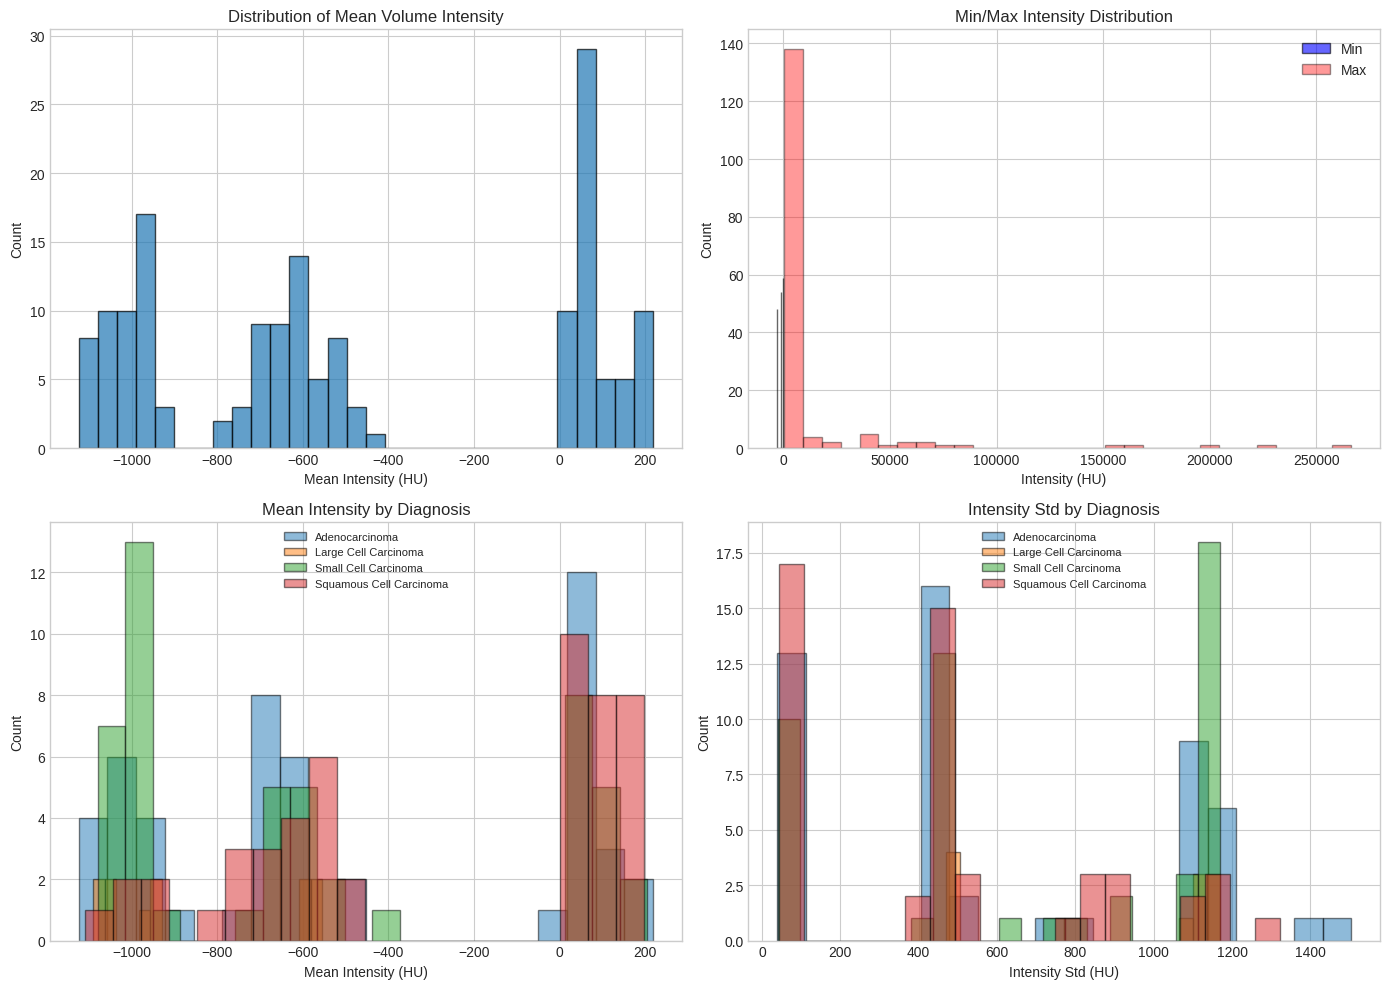

In [ ]:
# Intensity visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean intensity distribution
axes[0, 0].hist(df_intensity['hu_mean'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Mean Intensity (HU)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Mean Volume Intensity')

# Min / Max
axes[0, 1].hist(df_intensity['hu_min'].dropna(), bins=30, edgecolor='black', alpha=0.6, color='blue', label='Min')
axes[0, 1].hist(df_intensity['hu_max'].dropna(), bins=30, edgecolor='black', alpha=0.4, color='red', label='Max')
axes[0, 1].set_xlabel('Intensity (HU)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Min/Max Intensity Distribution')
axes[0, 1].legend()

# Mean intensity by diagnosis
for diag in sorted(df_intensity['diagnosis'].unique()):
    vals = df_intensity[df_intensity['diagnosis'] == diag]['hu_mean'].dropna()
    axes[1, 0].hist(vals, bins=20, alpha=0.5, label=diag, edgecolor='black')
axes[1, 0].set_xlabel('Mean Intensity (HU)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Mean Intensity by Diagnosis')
axes[1, 0].legend(fontsize=8)

# Std by diagnosis
for diag in sorted(df_intensity['diagnosis'].unique()):
    vals = df_intensity[df_intensity['diagnosis'] == diag]['hu_std'].dropna()
    axes[1, 1].hist(vals, bins=20, alpha=0.5, label=diag, edgecolor='black')
axes[1, 1].set_xlabel('Intensity Std (HU)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Intensity Std by Diagnosis')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('intensity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Windowing recommendations
print("=" * 60)
print("CT WINDOWING PARAMETERS (from dataset documentation)")
print("=" * 60)

windows = {
    'Lung':        {'level': -700, 'width': 1400},
    'Mediastinum':  {'level': 40,   'width': 350},
}

for name, params in windows.items():
    lo = params['level'] - params['width'] / 2
    hi = params['level'] + params['width'] / 2
    print(f"  {name:15s}: Level={params['level']:>5}, Width={params['width']:>5}  →  HU range [{lo:.0f}, {hi:.0f}]")

print("\nThese are the clinical windows used in the original study.")
print("For model training, you may apply one or both windows as input channels.")

CT WINDOWING PARAMETERS (from dataset documentation)
  Lung           : Level= -700, Width= 1400  →  HU range [-1400, 0]
  Mediastinum    : Level=   40, Width=  350  →  HU range [-135, 215]

These are the clinical windows used in the original study.
For model training, you may apply one or both windows as input channels.


## 7. Visual Samples (Lung & Mediastinum Windows)

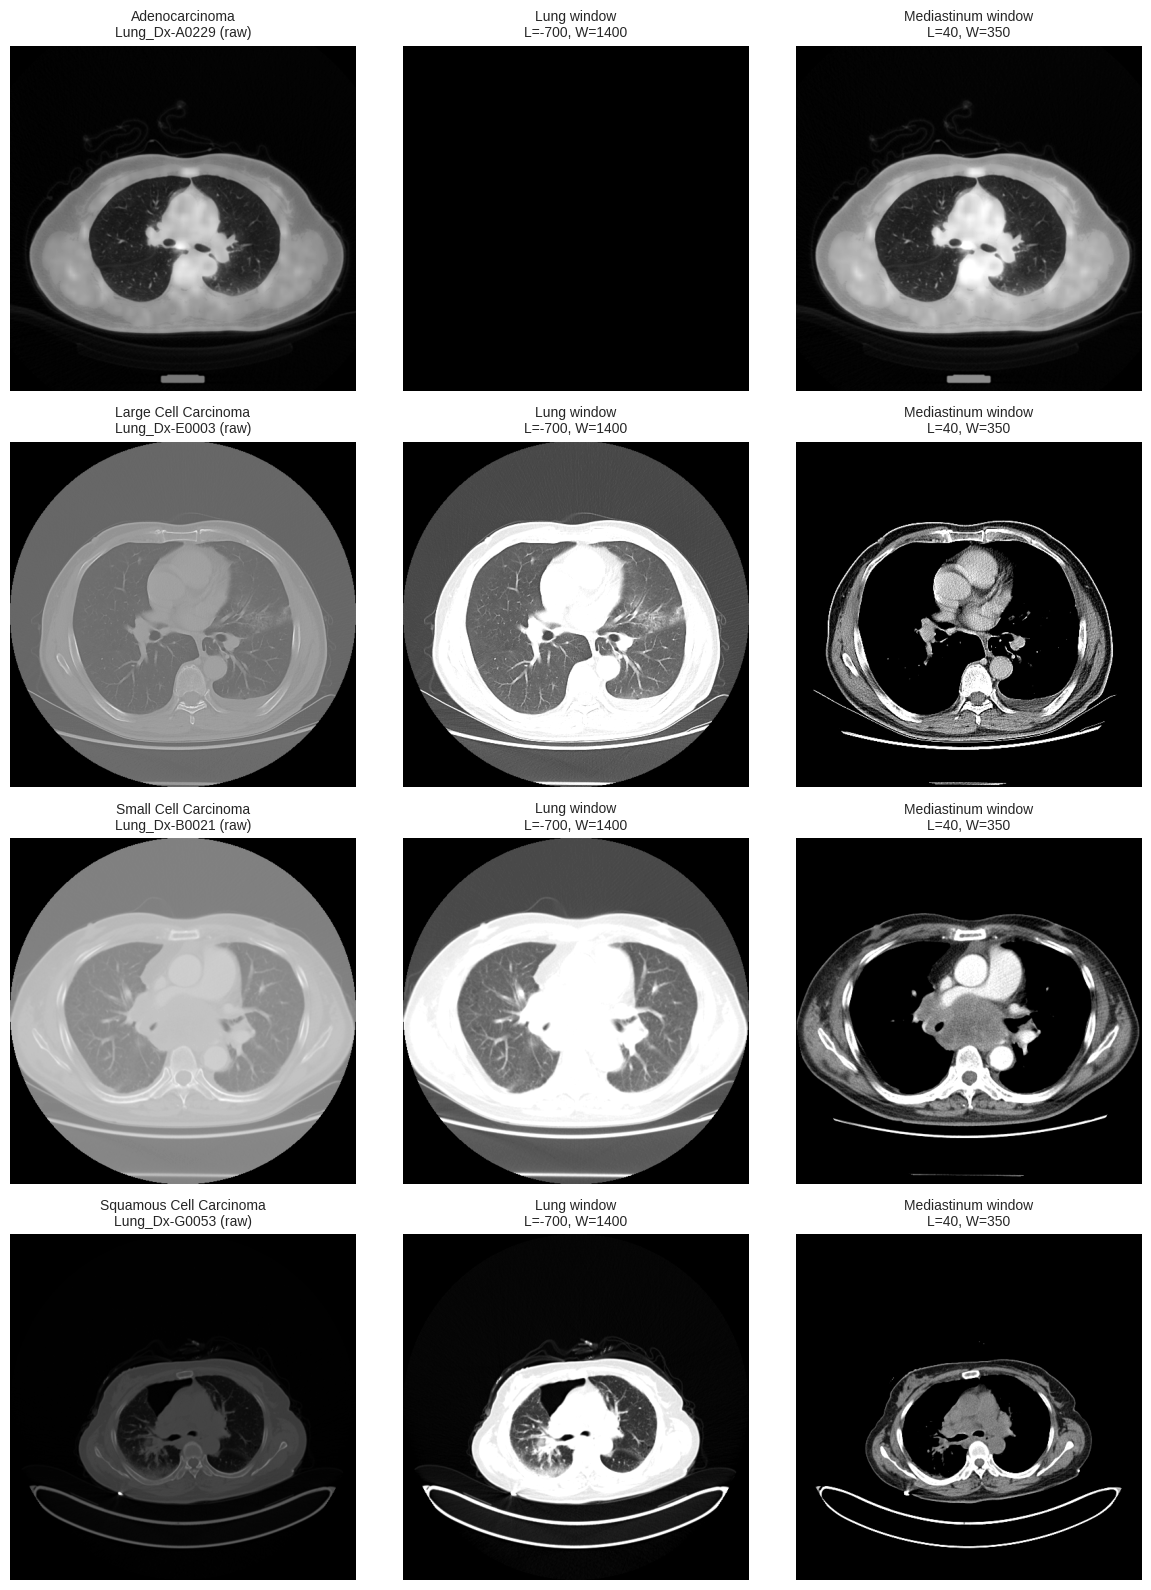

In [ ]:
def apply_window(data, level, width):
    """Apply CT window (level/width) and normalize to [0, 1]."""
    lo = level - width / 2
    hi = level + width / 2
    windowed = np.clip(data, lo, hi)
    windowed = (windowed - lo) / (hi - lo)
    return windowed


def visualize_samples(df, n_per_class=1):
    """Show one sample per class with lung and mediastinum windows."""
    classes = sorted(df['diagnosis'].unique())
    n_classes = len(classes)
    
    fig, axes = plt.subplots(n_per_class * n_classes, 3, figsize=(12, 4 * n_per_class * n_classes))
    if n_per_class * n_classes == 1:
        axes = axes.reshape(1, -1)
    
    row_idx = 0
    for diag in classes:
        sub = df[df['diagnosis'] == diag]
        samples = sub.sample(min(n_per_class, len(sub)), random_state=42)
        
        for _, srow in samples.iterrows():
            img, data = safe_load_nifti(srow['volume_path'])
            
            # Handle non-3D data (e.g. 4D time series/RGB, or 2D)
            if data.ndim == 4:
                # If 4D, assume first channel/volume is what we want
                data = data[..., 0]
            elif data.ndim == 2:
                # If 2D (H, W), add depth dimension
                data = data[:, :, np.newaxis]
            
            mid_z = data.shape[2] // 2
            sl = data[:, :, mid_z]
            
            # Raw
            axes[row_idx, 0].imshow(sl.T, cmap='gray', origin='lower')
            axes[row_idx, 0].set_title(f"{diag}\n{srow['patient_id']} (raw)", fontsize=10)
            axes[row_idx, 0].axis('off')
            
            # Lung window
            lung = apply_window(sl, level=-700, width=1400)
            axes[row_idx, 1].imshow(lung.T, cmap='gray', origin='lower')
            axes[row_idx, 1].set_title('Lung window\nL=-700, W=1400', fontsize=10)
            axes[row_idx, 1].axis('off')
            
            # Mediastinum window
            med = apply_window(sl, level=40, width=350)
            axes[row_idx, 2].imshow(med.T, cmap='gray', origin='lower')
            axes[row_idx, 2].set_title('Mediastinum window\nL=40, W=350', fontsize=10)
            axes[row_idx, 2].axis('off')
            
            row_idx += 1
    
    plt.tight_layout()
    plt.savefig('sample_slices_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()

# Only use CT volumes for visualization
df_ct = df.merge(df_json[df_json['Modality'] == 'CT'][['patient_id', 'series_uid']], on=['patient_id', 'series_uid'], how='inner')
if len(df_ct) == 0:
    df_ct = df  # fallback if merge is empty

visualize_samples(df_ct, n_per_class=1)

## 8. Per-Class Dimension & Spacing Comparison

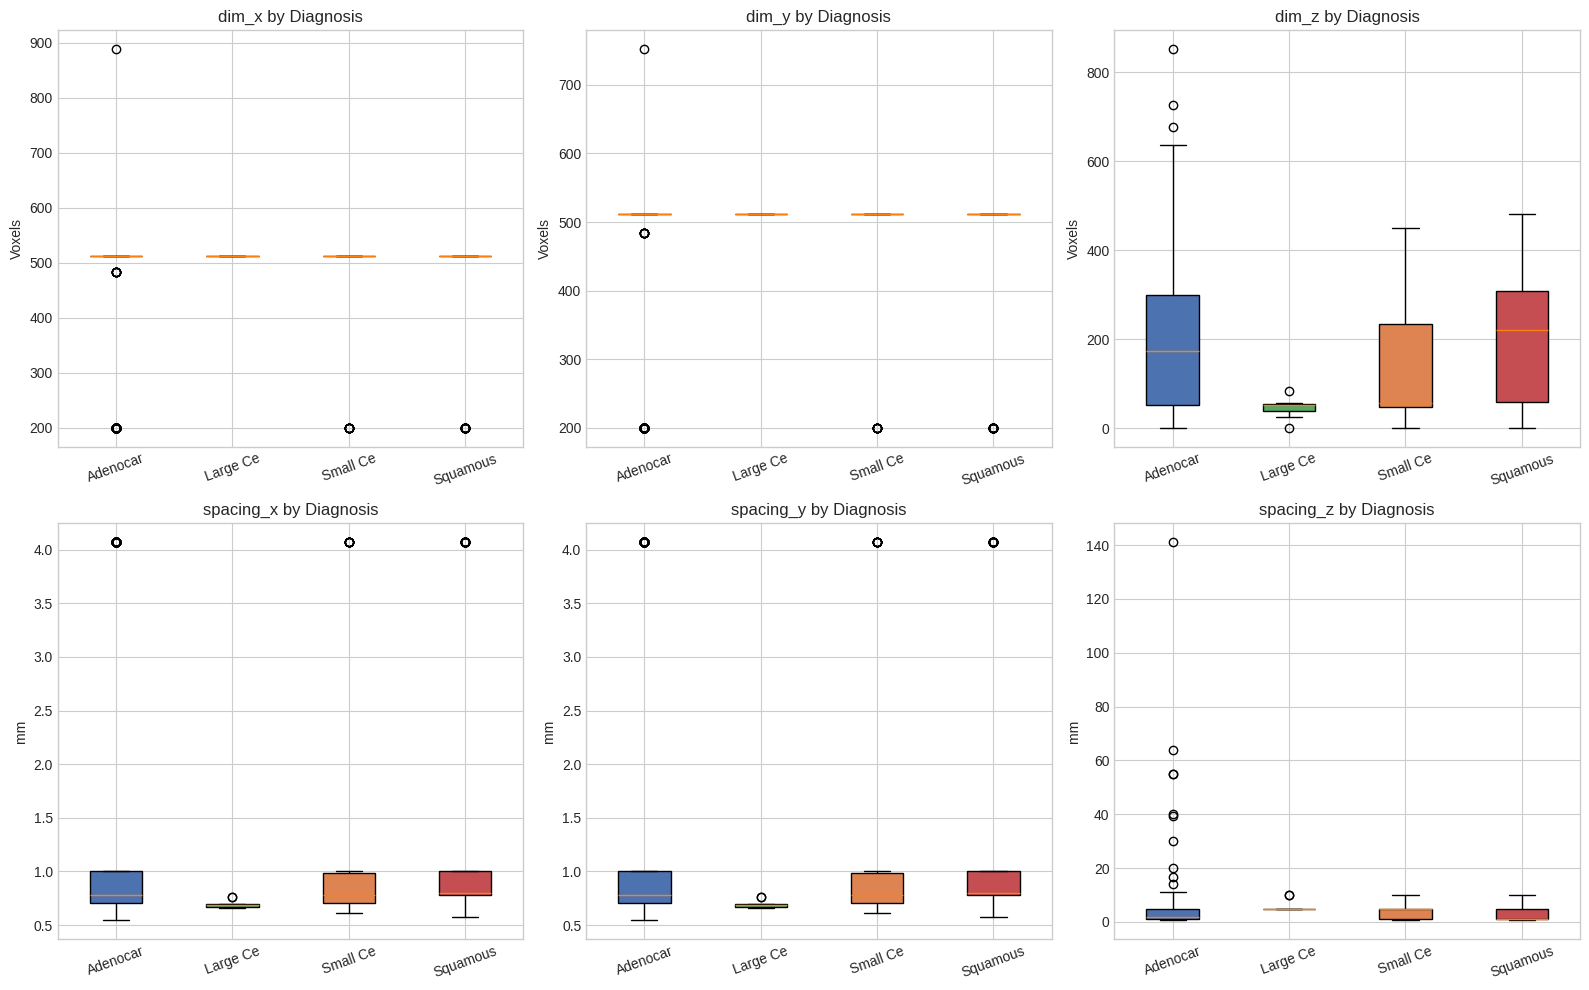

In [12]:
# Boxplots comparing dimensions and spacing across classes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

diag_order = sorted(df_nifti['diagnosis'].unique())

for i, col in enumerate(['dim_x', 'dim_y', 'dim_z']):
    data_groups = [df_nifti[df_nifti['diagnosis'] == d][col].dropna().values for d in diag_order]
    bp = axes[0, i].boxplot(data_groups, labels=[d[:8] for d in diag_order], patch_artist=True)
    for patch, d in zip(bp['boxes'], diag_order):
        patch.set_facecolor(COLOR_MAP.get(d, 'gray'))
    axes[0, i].set_ylabel('Voxels')
    axes[0, i].set_title(f'{col} by Diagnosis')
    axes[0, i].tick_params(axis='x', rotation=20)

for i, col in enumerate(['spacing_x', 'spacing_y', 'spacing_z']):
    data_groups = [df_nifti[df_nifti['diagnosis'] == d][col].dropna().values for d in diag_order]
    bp = axes[1, i].boxplot(data_groups, labels=[d[:8] for d in diag_order], patch_artist=True)
    for patch, d in zip(bp['boxes'], diag_order):
        patch.set_facecolor(COLOR_MAP.get(d, 'gray'))
    axes[1, i].set_ylabel('mm')
    axes[1, i].set_title(f'{col} by Diagnosis')
    axes[1, i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('dimensions_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary Statistics Table

In [13]:
# Compile summary statistics
rows = []

rows.append(('Total NIfTI volumes', len(df), 'scans'))
rows.append(('Unique patients', df['patient_id'].nunique(), 'patients'))
for diag in sorted(df['diagnosis'].unique()):
    n_vol = (df['diagnosis'] == diag).sum()
    n_pat = df[df['diagnosis'] == diag]['patient_id'].nunique()
    rows.append((f'  {diag} (volumes)', n_vol, 'scans'))
    rows.append((f'  {diag} (patients)', n_pat, 'patients'))

if len(df_json) > 0:
    n_ct = (df_json['Modality'] == 'CT').sum()
    n_pt = (df_json['Modality'] == 'PT').sum()
    rows.append(('CT modality volumes', n_ct, 'scans'))
    rows.append(('PT modality volumes', n_pt, 'scans'))

if len(df_nifti) > 0:
    rows.append(('Median X dim', f"{df_nifti['dim_x'].median():.0f}", 'voxels'))
    rows.append(('Median Y dim', f"{df_nifti['dim_y'].median():.0f}", 'voxels'))
    rows.append(('Median Z dim (depth)', f"{df_nifti['dim_z'].median():.0f}", 'slices'))
    rows.append(('Median pixel spacing', f"{df_nifti['spacing_x'].median():.3f}", 'mm'))
    rows.append(('Median slice spacing', f"{df_nifti['spacing_z'].median():.3f}", 'mm'))
    rows.append(('Slice spacing range', f"[{df_nifti['spacing_z'].min():.3f}, {df_nifti['spacing_z'].max():.3f}]", 'mm'))

if len(df_intensity) > 0:
    rows.append(('Mean volume intensity (sampled)', f"{df_intensity['hu_mean'].mean():.1f}", 'HU'))
    rows.append(('Volume intensity range', f"[{df_intensity['hu_min'].min():.0f}, {df_intensity['hu_max'].max():.0f}]", 'HU'))

df_summary = pd.DataFrame(rows, columns=['Metric', 'Value', 'Unit'])
print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df_summary.to_string(index=False))

# Save
output_dir = os.path.dirname(os.path.abspath('data_expl.ipynb'))
df_summary.to_csv(os.path.join(output_dir, 'eda_summary.csv'), index=False)
print(f"\n✓ Summary saved to eda_summary.csv")

NameError: name 'df_intensity' is not defined

## 10. Recommendations for Model Training

In [ ]:
print("=" * 60)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("=" * 60)

recommendations = []

# Class imbalance
vol_counts = df['diagnosis'].value_counts()
imbalance = vol_counts.max() / vol_counts.min()
if imbalance > 10:
    recommendations.append(
        f"⚠️  Severe class imbalance ({imbalance:.0f}x). "
        "Use oversampling (SMOTE), weighted loss, or stratified sampling."
    )
elif imbalance > 3:
    recommendations.append(
        f"⚠️  Moderate class imbalance ({imbalance:.0f}x). "
        "Consider class-weighted loss or stratified sampling."
    )
else:
    recommendations.append("✓  Class balance is reasonable.")

# Modality
if len(df_json) > 0:
    n_pt = (df_json['Modality'] == 'PT').sum()
    if n_pt > 0:
        recommendations.append(
            f"ℹ️  {n_pt} PET volumes detected. Filter to CT-only for training "
            "unless multi-modal approach is intended."
        )

# Spacing
if len(df_nifti) > 0:
    spacing_std = df_nifti[['spacing_x', 'spacing_y', 'spacing_z']].std().max()
    if spacing_std > 0.5:
        recommendations.append(
            "⚠️  Variable voxel spacing detected. Resample to isotropic voxels "
            "(e.g., 1mm³) before training."
        )
    else:
        recommendations.append("✓  Voxel spacing is relatively consistent.")

    dim_std = df_nifti[['dim_x', 'dim_y']].std().mean()
    if dim_std > 50:
        recommendations.append(
            "⚠️  High variance in image dimensions. Center-crop or pad to a "
            "fixed size (e.g., 224×224 for ViT/ResNet)."
        )

# Multiple series per patient
series_per_patient = df.groupby('patient_id').size()
if series_per_patient.max() > 1:
    recommendations.append(
        f"ℹ️  Patients have 1–{series_per_patient.max()} series. "
        "Decide whether to use one representative series per patient "
        "(avoid data leakage in train/val/test splits) or all series."
    )

# General
recommendations.append("")
recommendations.append("📋 GENERAL RECOMMENDATIONS:")
recommendations.append("   • Apply HU windowing before normalization:")
recommendations.append("     - Lung window: L=-700, W=1400 (for parenchyma)")
recommendations.append("     - Mediastinum window: L=40, W=350 (for soft tissue)")
recommendations.append("   • Normalize to [0,1] or [-1,1] after windowing")
recommendations.append("   • Split by PATIENT (not volume) to prevent data leakage")
recommendations.append("   • For 2D models (ResNet/DenseNet/ViT): resize to 224×224 or 384×384")
recommendations.append("   • Consider 2.5D approach (adjacent slices as channels) for 2D models")
recommendations.append("   • For 3D models: consider fixed depth (e.g., 64 or 128 slices)")

for r in recommendations:
    print(r)

RECOMMENDATIONS FOR MODEL TRAINING
⚠️  Severe class imbalance (91x). Use oversampling (SMOTE), weighted loss, or stratified sampling.
ℹ️  37 PET volumes detected. Filter to CT-only for training unless multi-modal approach is intended.
⚠️  Variable voxel spacing detected. Resample to isotropic voxels (e.g., 1mm³) before training.
⚠️  High variance in image dimensions. Center-crop or pad to a fixed size (e.g., 224×224 for ViT/ResNet).
ℹ️  Patients have 1–14 series. Decide whether to use one representative series per patient (avoid data leakage in train/val/test splits) or all series.

📋 GENERAL RECOMMENDATIONS:
   • Apply HU windowing before normalization:
     - Lung window: L=-700, W=1400 (for parenchyma)
     - Mediastinum window: L=40, W=350 (for soft tissue)
   • Normalize to [0,1] or [-1,1] after windowing
   • Split by PATIENT (not volume) to prevent data leakage
   • For 2D models (ResNet/DenseNet/ViT): resize to 224×224 or 384×384
   • Consider 2.5D approach (adjacent slices as 

Searching for annotations in /home/data/Annotation_ZMapped...
patient_id                                          Lung_Dx-A0004
class_letter                                                    A
patient_num                                                  0004
series_uid      1.3.6.1.4.1.14519.5.2.1.6655.2359.128573427051...
diagnosis                                          Adenocarcinoma
volume_path     /home/data/Lung-PET-CT-Dx/Lung_Dx-A0004_1.3.6....
json_path       /home/data/Lung-PET-CT-Dx/Lung_Dx-A0004_1.3.6....
has_json                                                     True
Name: 10, dtype: object


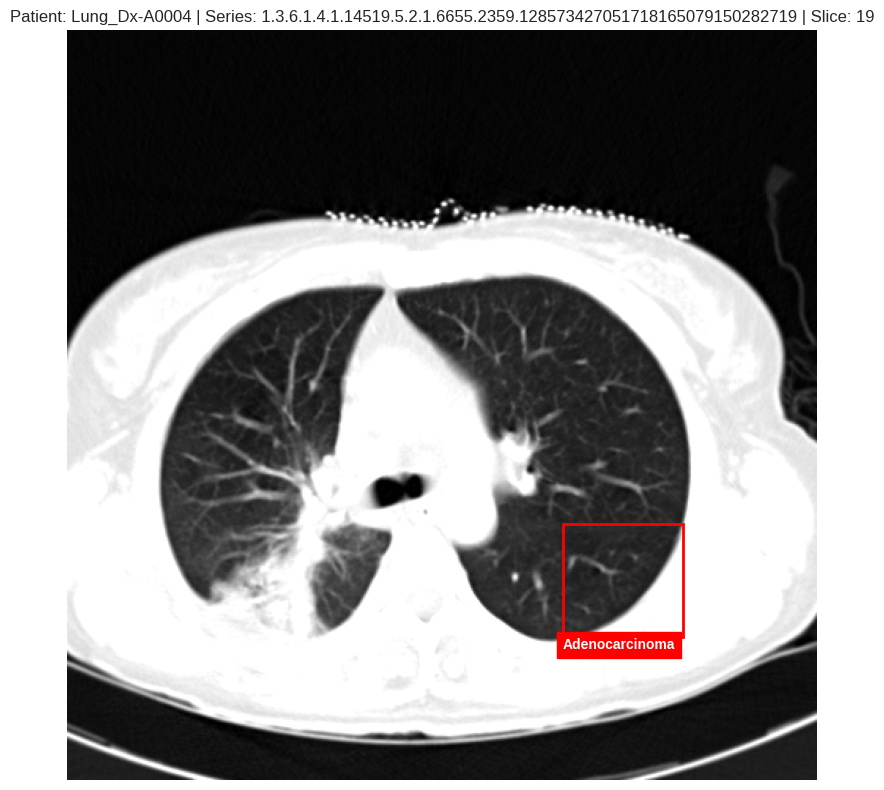

In [14]:
import os
import glob
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Update this path to wherever your Lung-PET-CT-Dx annotations are stored
ANNOTATION_DIR = "/home/data/Annotation_ZMapped" 

def visualize_slice_with_bbox(volume_path, annotation_dir):
    """Loads a NIfTI volume, finds its corresponding XML annotations, and plots the bounding boxes."""
    patient_id, class_letter, patient_num, series_uid, diagnosis = parse_filename(volume_path)
    if patient_id is None:
        return False
        
    short_id = patient_id.split("-")[-1]
    patient_annot_dir = os.path.join(annotation_dir, short_id)
    
    if not os.path.isdir(patient_annot_dir):
        return False
        
    # Find XML files for this specific series
    xml_pattern = os.path.join(patient_annot_dir, f"*_{series_uid}_slice*.xml")
    xml_files = glob.glob(xml_pattern)
    
    if not xml_files:
        return False
        
    # Get the first available XML annotation to visualize
    xml_path = xml_files[0]
    slice_str = xml_path.split("_slice")[-1].replace(".xml", "")
    slice_idx = int(slice_str)
    
    # Parse bounding boxes from XML
    tree = ET.parse(xml_path)
    root = tree.getroot()
    bboxes = []
    
    for obj in root.findall("object"):
        name_elem = obj.find("name")
        if name_elem is None:
            continue
        letter = name_elem.text.strip()
        
        bbox = obj.find("bndbox")
        if bbox is not None:
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)
            bboxes.append((letter, xmin, ymin, xmax, ymax))
            
    if not bboxes:
        return False

    # Load volume and grab the specific annotated slice
    _, data = safe_load_nifti(volume_path)
    
    if slice_idx >= data.shape[2]:
        print(f"Warning: Slice index {slice_idx} out of bounds for depth {data.shape[2]}.")
        return False

    slice_data = data[:, :, slice_idx]
    
    # Apply Lung Window for clarity
    slice_windowed = apply_window(slice_data, level=-700, width=1400)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    # Keep transpose for visual consistency with earlier notebook plots
    ax.imshow(slice_windowed.T, cmap='gray', origin='lower')
    
    # Draw boxes in transposed display coordinates (x' = y, y' = x)
    for letter, xmin, ymin, xmax, ymax in bboxes:
        width = xmax - xmin 
        height = ymax - ymin 
        class_name = CLASS_MAP.get(letter, letter)

        # Because image is transposed: rectangle(x, y, w, h) -> (ymin, xmin, height, width)
        rect = patches.Rectangle((ymin, xmin), height, width, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(ymin, max(xmin - 8, 0), f"{class_name}", color='white', fontsize=10,
                backgroundcolor='red', fontweight='bold')
        
    ax.set_title(f"Patient: {patient_id} | Series: {series_uid} | Slice: {slice_idx}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return True

# Loop through the inventory until we find and plot a valid annotation
print(f"Searching for annotations in {ANNOTATION_DIR}...")
found = False
for _, row in df.iterrows():
    
    if row['patient_id'] == 'Lung_Dx-A0004':
        print(row)
        if visualize_slice_with_bbox(row['volume_path'], ANNOTATION_DIR):
            found = True
            break

if not found:
    print("Could not find any overlapping NIfTI volumes and XML annotations to visualize. Check your ANNOTATION_DIR path.")

Searching DICOM series in /home/data/Lung-PET-CT-Dx_dicom and annotations in /home/data/Annotation_ZMapped...


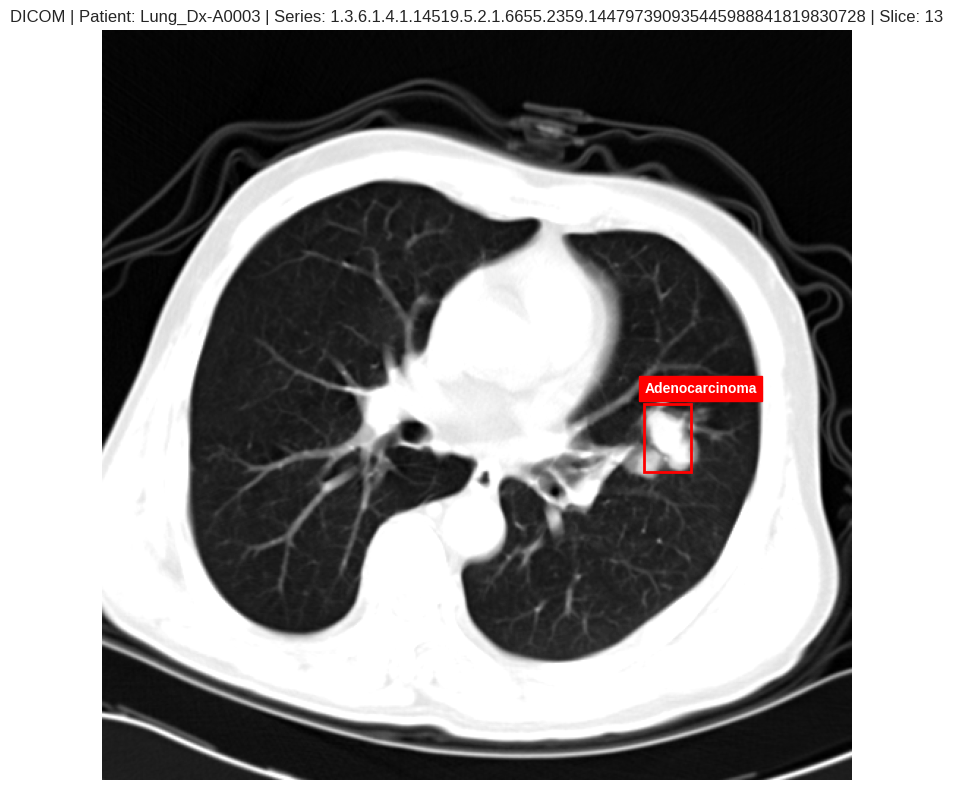

In [15]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

try:
    import pydicom
except ImportError:
    raise ImportError("pydicom is required for DICOM visualization. Install it with: pip install pydicom")

# Root directory containing DICOM files (can be changed if needed)
DICOM_ROOT_DIR = "/home/data/Lung-PET-CT-Dx_dicom"
ANNOTATION_DIR = "/home/data/Annotation_ZMapped"

def _collect_dicom_candidates(series_uid, dicom_root_dir):
    """Find candidate DICOM files for a given series UID."""
    # 1) Fast path: UID appears in file/folder names
    uid_hits = glob.glob(os.path.join(dicom_root_dir, f"**/*{series_uid}*"), recursive=True)
    dicom_files = []

    for p in uid_hits:
        if os.path.isdir(p):
            dicom_files.extend(glob.glob(os.path.join(p, "*.dcm")))
        elif p.lower().endswith(".dcm"):
            dicom_files.append(p)

    # 2) Fallback: search all .dcm and filter by SeriesInstanceUID header
    if not dicom_files:
        all_dcm = glob.glob(os.path.join(dicom_root_dir, "**/*.dcm"), recursive=True)
        for fp in all_dcm:
            try:
                ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
                if str(getattr(ds, "SeriesInstanceUID", "")) == str(series_uid):
                    dicom_files.append(fp)
            except Exception:
                continue

    return sorted(list(set(dicom_files)))

def _load_dicom_volume(dicom_files):
    """Load DICOM series into a volume array with shape [H, W, Z] in HU."""
    slices = []
    for fp in dicom_files:
        try:
            ds = pydicom.dcmread(fp, force=True)
            if not hasattr(ds, "pixel_array"):
                continue

            arr = ds.pixel_array.astype(np.float32)
            slope = float(getattr(ds, "RescaleSlope", 1.0))
            intercept = float(getattr(ds, "RescaleIntercept", 0.0))
            arr = arr * slope + intercept

            if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) >= 3:
                z_pos = float(ds.ImagePositionPatient[2])
            else:
                z_pos = float(getattr(ds, "InstanceNumber", len(slices)))

            slices.append((z_pos, arr, ds))
        except Exception:
            continue

    if not slices:
        return None

    slices.sort(key=lambda x: x[0])
    volume = np.stack([s[1] for s in slices], axis=-1)
    return volume

def visualize_dicom_slice_with_bbox(volume_path, annotation_dir, dicom_root_dir):
    """Load DICOM series for a volume and overlay XML bounding boxes on the annotated slice."""
    patient_id, class_letter, patient_num, series_uid, diagnosis = parse_filename(volume_path)
    if patient_id is None:
        return False

    short_id = patient_id.split("-")[-1]
    patient_annot_dir = os.path.join(annotation_dir, short_id)
    if not os.path.isdir(patient_annot_dir):
        return False

    xml_pattern = os.path.join(patient_annot_dir, f"*_{series_uid}_slice*.xml")
    xml_files = sorted(glob.glob(xml_pattern))
    if not xml_files:
        return False

    xml_path = xml_files[0]
    slice_str = xml_path.split("_slice")[-1].replace(".xml", "")
    slice_idx = int(slice_str)

    tree = ET.parse(xml_path)
    root = tree.getroot()
    bboxes = []
    for obj in root.findall("object"):
        name_elem = obj.find("name")
        bbox = obj.find("bndbox")
        if name_elem is None or bbox is None:
            continue
        letter = name_elem.text.strip()
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)
        bboxes.append((letter, xmin, ymin, xmax, ymax))

    if not bboxes:
        return False

    dicom_files = _collect_dicom_candidates(series_uid, dicom_root_dir)
    if not dicom_files:
        print(f"No DICOM files found for series {series_uid} in {dicom_root_dir}")
        return False

    volume = _load_dicom_volume(dicom_files)
    if volume is None:
        print("Could not load a valid DICOM volume.")
        return False

    if slice_idx >= volume.shape[2]:
        print(f"Warning: XML slice {slice_idx} out of bounds for DICOM depth {volume.shape[2]}. Using nearest valid slice.")
        slice_idx = min(slice_idx, volume.shape[2] - 1)

    slice_data = volume[:, :, slice_idx]
    slice_windowed = apply_window(slice_data, level=-700, width=1400)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(slice_windowed, cmap='gray', origin='upper')

    for letter, xmin, ymin, xmax, ymax in bboxes:
        width = xmax - xmin
        height = ymax - ymin
        class_name = CLASS_MAP.get(letter, letter)
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, max(ymin - 8, 0), class_name, color='white', fontsize=10,
                backgroundcolor='red', fontweight='bold')

    ax.set_title(f"DICOM | Patient: {patient_id} | Series: {series_uid} | Slice: {slice_idx}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    return True

print(f"Searching DICOM series in {DICOM_ROOT_DIR} and annotations in {ANNOTATION_DIR}...")
found = False
for _, row in df.iterrows():
    if row['patient_id'] == 'Lung_Dx-A0003':
        if visualize_dicom_slice_with_bbox(row['volume_path'], ANNOTATION_DIR, DICOM_ROOT_DIR):
            found = True
            break

if not found:
    print("No matching DICOM/XML pair could be visualized. Check DICOM_ROOT_DIR and ANNOTATION_DIR.")

In [16]:
from data.data_loader import get_lung_pet_ct_dx_data_list, CLASS_NAMES
from data.transforms import get_train_transforms_3d
import matplotlib.patches as patches
import torch

ANNOTATION_DIR = "/home/data/Annotation_ZMapped"
DATA_DIR = "/home/data/Lung-PET-CT-Dx"

print("=" * 60)
print("11. DATA LOADER & AUGMENTATION PIPELINE DEMONSTRATION")
print("=" * 60)

# Fetch dataloader list using our pipeline
print("Scanning dataset and matching with XML annotations...")
data_splits = get_lung_pet_ct_dx_data_list(
    data_path=DATA_DIR,
    val_frac=0.1,
    test_frac=0.1,
    seed=42,
    annotation_dir=ANNOTATION_DIR,
    testing=False,
    img_size=224
)

train_list = data_splits['train']
# Find a sample that has valid bounding boxes
annotated_samples = [item for item in train_list if item.get("boxes") is not None and len(item["boxes"]) > 0]

if not annotated_samples:
    print(f"No annotated samples found matching the rules in {ANNOTATION_DIR}")
else:
    sample_to_visualize = annotated_samples[0]
    print(f"Visualizing Sample: {os.path.basename(sample_to_visualize['image'])}")
    print(f"Original label logic ID: {sample_to_visualize['scan_label']}")
    print(f"Raw bounding boxes: {sample_to_visualize['boxes']}")
    
    # Instantiate our pipeline's 3D transforms
    transforms = get_train_transforms_3d(img_size=224, depth_size=64)
    
    # Process the sample
    transformed_sample = transforms(sample_to_visualize)
    
    # Extract tensor data
    img_tensor = transformed_sample["image"]  # SHAPE: (C, X, Y, Z) expected
    boxes = transformed_sample["boxes"]
    labels = transformed_sample["labels"]
    
    print(f"Transformed Image Shape: {img_tensor.shape}")
    print(f"Transformed Target Boxes (X, Y mapped to 224, Z centered to 64 depth): {boxes}")
    
    # Visualization setup
    if len(boxes) > 0:
        box = boxes[0]  # [x1, y1, z1, x2, y2, z2]
        
        # Get the Z-center of the newly padded/cropped depth
        if len(box) == 6:
            z_center = int((box[2] + box[5]) / 2)
            # Clip index to tensor dimensions
            z_idx = min(max(z_center, 0), img_tensor.shape[-1] - 1)
        else:
            z_idx = img_tensor.shape[-1] // 2
            
        print(f"Visualizing sliced volume at Z = {z_idx}")
        
        # We assume single-channel CT data in transformed output
        slice_data = img_tensor[0, :, :, z_idx].numpy()
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Center slice with bounding box
        ax = axes[0]
        # Keep transpose for consistency with earlier plots
        ax.imshow(slice_data.T, cmap='gray', origin='lower')
        
        x1, y1, z1, x2, y2, z2 = box[0], box[1], box[2], box[3], box[4], box[5]
        width_box, height_box = x2 - x1, y2 - y1

        # Because image is transposed: rectangle(x, y, w, h) -> (y1, x1, h, w)
        rect = patches.Rectangle((y1, x1), height_box, width_box, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        class_name = CLASS_NAMES[labels[0] - 1] if labels[0] - 1 < len(CLASS_NAMES) else f"Class {labels[0]}"
        ax.text(y1, max(x1 - 5, 0), class_name, color='white', fontsize=10, backgroundcolor='red', fontweight='bold')
        ax.set_title(f"Z-Slice: {z_idx} (Center of Tumor)")
        ax.axis('off')
        
        # Slices immediately before and after (for 3D context)
        offset = 3
        z_prev = max(0, z_idx - offset)
        z_next = min(img_tensor.shape[-1] - 1, z_idx + offset)
        
        axes[1].imshow(img_tensor[0, :, :, z_prev].numpy().T, cmap='gray', origin='lower')
        axes[1].set_title(f"Z-Slice: {z_prev} (-{offset})")
        axes[1].axis('off')
        
        axes[2].imshow(img_tensor[0, :, :, z_next].numpy().T, cmap='gray', origin='lower')
        axes[2].set_title(f"Z-Slice: {z_next} (+{offset})")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

ModuleNotFoundError: No module named 'data'

In [ ]:
# Save all dataframes for downstream use
df.to_csv('data_inventory.csv', index=False)
print("✓ Saved: data_inventory.csv")

if len(df_json) > 0:
    df_json.to_csv('json_metadata.csv', index=False)
    print("✓ Saved: json_metadata.csv")

if len(df_nifti) > 0:
    df_nifti.to_csv('nifti_metadata.csv', index=False)
    print("✓ Saved: nifti_metadata.csv")

if len(df_intensity) > 0:
    df_intensity.to_csv('intensity_analysis.csv', index=False)
    print("✓ Saved: intensity_analysis.csv")

print("\n" + "=" * 60)
print("DATA EXPLORATION COMPLETE")
print("=" * 60)

✓ Saved: data_inventory.csv
✓ Saved: json_metadata.csv
✓ Saved: nifti_metadata.csv
✓ Saved: intensity_analysis.csv

DATA EXPLORATION COMPLETE
